# Task D and E: Customer Churn Prediction (Machine Learning and Deep Learning)

**What is churn?** A customer who used to buy but has stopped buying. If the company knows this in advance, it can send an offer and try to keep the customer.

**Our question:** by looking at the purchase history, can we tell whether a customer will buy again in the next 3 months or not?

### The churn setup from the brief
- **Features** are built only from orders up to 31 May 2026.
- **Target window:** 1 June 2026 to 31 August 2026.
- For a customer who bought on or before 31 May: **churn = 1** if there is no order in the target window, otherwise **churn = 0**.
- **Avoid data leakage:** we must not give the model information from the future. No order after 31 May may be used in the features.

### Timeline

```
   PAST (features come from here)      |   FUTURE (target comes from here)
 --------------------------------- 31 May 2026 ------------------------------- 31 Aug 2026
  look at old orders and build         1 Jun - 31 Aug: did the customer buy anything?
  numbers about the customer           No = churn 1,  Yes = churn 0
```

### Data leakage: an example
If you got the **answers of an exam paper** before the exam, you would score 100, but that is not your real ability. In the same way, if we give the model data from after 1 June as a feature, it already knows the answer and its score is fake. So features use only orders up to **31 May**, and the target uses only the orders **after** that.

## Step 1: Libraries and Database

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

conn = sqlite3.connect("ecommerce_hackathon.db")

def run_sql(q):
    return pd.read_sql_query(q, conn)

## Step 2: Load and clean the data

This is the same cleaning that was done in notebook 01 (Task A), so only the code is repeated here and the reasons are written there:
- fix city names and fill the missing `age` with the median
- orders: drop rows with an invalid date or quantity 0, replace negative prices with the catalog price, fill missing `delivery_days` with the median
- `net_revenue = quantity x price x (1 - discount)`

In [2]:
customers = run_sql("select * from customers")
products = run_sql("select * from products")
orders = run_sql("select * from orders")

# customers
customers["city"] = customers["city"].str.strip().str.title()
customers["age"] = customers["age"].fillna(customers["age"].median())
customers["signup_date"] = pd.to_datetime(customers["signup_date"])

# orders
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
orders = orders.dropna(subset=["order_date"])
orders = orders[orders["quantity"] > 0]
orders = orders.merge(products[["product_id", "unit_price"]], on="product_id", suffixes=("", "_catalog"))
bad_price = orders["unit_price"] <= 0
orders.loc[bad_price, "unit_price"] = orders.loc[bad_price, "unit_price_catalog"]
orders = orders.drop(columns="unit_price_catalog")
orders["delivery_days"] = orders["delivery_days"].fillna(orders["delivery_days"].median())
orders["net_revenue"] = orders["quantity"] * orders["unit_price"] * (1 - orders["discount"])

print("customers:", customers.shape, "| orders:", orders.shape)

customers: (8000, 9) | orders: (64925, 11)


## Step 3: Split the orders into the past and the target window

We fix two dates:
- `CUTOFF = 31 May 2026`: the **features** are built from orders up to this date (the "past").
- `TARGET_END = 31 Aug 2026`: the orders from 1 June to this date are used **only to make the target** (churn) (the "future").

In [3]:
CUTOFF = pd.Timestamp("2026-05-31")
TARGET_END = pd.Timestamp("2026-08-31")

past_orders = orders[orders["order_date"] <= CUTOFF]
future_orders = orders[(orders["order_date"] > CUTOFF) & (orders["order_date"] <= TARGET_END)]

print("past orders  :", len(past_orders), "(features are built from these)")
print("future orders:", len(future_orders), "(used only for the target)")

past orders  : 49669 (features are built from these)
future orders: 15256 (used only for the target)


## Step 4: Build the features (from past orders only)

`groupby("customer_id")` puts the orders of each customer into one group, and `agg(...)` creates one summary row per customer from each group.

| Feature | Meaning |
|---|---|
| `total_orders` | how many orders the customer made |
| `total_spending` | how much money the customer spent in total |
| `avg_order_value` | the average of one order (total spending / total orders) |
| `days_since_last_order` | how many days passed between the last order and 31 May |
| `return_rate` | the share of orders that were returned |
| `avg_delivery_days` | average number of delivery days |
| `age` | the customer's age |
| `membership_type` | Standard / Silver / Gold / Premium |
| `tenure_days` | **extra feature:** how many days passed between the customer's signup and 31 May (how old the account is) |

In [4]:
features = past_orders.groupby("customer_id").agg(
    total_orders=("order_id", "count"),
    total_spending=("net_revenue", "sum"),
    return_rate=("returned", "mean"),
    avg_delivery_days=("delivery_days", "mean"),
    last_order_date=("order_date", "max"),
).reset_index()

features["avg_order_value"] = features["total_spending"] / features["total_orders"]
features["days_since_last_order"] = (CUTOFF - features["last_order_date"]).dt.days

# add age and membership from the customers table
features = features.merge(customers[["customer_id", "age", "membership_type", "signup_date"]], on="customer_id", how="left")

# extra feature: how old the account is on 31 May (in days)
features["tenure_days"] = (CUTOFF - features["signup_date"]).dt.days

print(features.shape)
features.head()

(6536, 12)


,customer_id,total_orders,total_spending,return_rate,avg_delivery_days,last_order_date,avg_order_value,days_since_last_order,age,membership_type,signup_date,tenure_days
0,2,3,6229.49896,0.0,4.666667,2026-05-28,2076.499653,3,33.0,Silver,2025-10-17,226
1,3,6,24102.46210,0.0,3.166667,2026-02-13,4017.077017,107,25.0,Standard,2022-07-11,1420
2,4,5,14400.81290,0.0,3.000000,2026-05-18,2880.162580,13,26.0,Standard,2025-02-23,462
3,5,8,76312.80669,0.0,3.500000,2026-05-12,9539.100836,19,27.0,Standard,2025-04-21,405
4,6,3,50020.16297,0.0,3.000000,2025-03-17,16673.387657,440,24.0,Standard,2023-07-24,1042


## Step 5: Create the target (churn)

A customer who made an order between 1 June and 31 Aug (so is in `future_orders`) gets `churn = 0`; everyone else gets `churn = 1`.

`isin(...)` checks whether the customer_id is in that list.

In [5]:
active_customers = set(future_orders["customer_id"])

features["churn"] = (~features["customer_id"].isin(active_customers)).astype(int)

print("Total customers:", len(features))
print(features["churn"].value_counts())
print("Churn rate:", round(features["churn"].mean() * 100, 1), "%")

Total customers: 6536
churn
0    3331
1    3205
Name: count, dtype: int64
Churn rate: 49.0 %


**Observation:** Churn and non-churn customers are almost equal (churn rate about 49%), so the data is **balanced**. Accuracy is a fair metric here, but we will also look at precision, recall and ROC-AUC.

**Which customers are included?** Out of 8,000 customers, only the **6,536** who made **at least one order up to 31 May** are used. By the brief, churn only makes sense for customers who used to buy. The rest either joined after 31 May or never bought anything, so they are not part of this model.

## Step 6: Leakage check

If we accidentally put data from after 31 May into the features, the model would be cheating. We check that no feature contains a date after 31 May.

In [6]:
print("Latest order date in the features:", features["last_order_date"].max().date(), "(must not be after the CUTOFF)")
print("No leakage:", features["last_order_date"].max() <= CUTOFF)

Latest order date in the features: 2026-05-31 (must not be after the CUTOFF)
No leakage: True


**What we did to avoid leakage:**
- All features are built only from `past_orders` (up to 31 May).
- `future_orders` is kept separate and none of its numbers became a feature.
- We do not give `last_order_date` to the model (we only used it to calculate `days_since_last_order`, which is measured at 31 May).

## Step 7: Separate features (X) and target (y), then Train-Test Split

- **X** = the features the model learns from. **y** = `churn`.
- Numeric and categorical columns are listed separately because they are prepared differently.
- **80% train, 20% test.** `stratify=y` keeps the same churn ratio in both parts. `random_state=42` gives the same split every time.

In [7]:
numeric_cols = ["total_orders", "total_spending", "avg_order_value",
                "days_since_last_order", "return_rate", "avg_delivery_days", "age", "tenure_days"]
categorical_cols = ["membership_type"]

X = features[numeric_cols + categorical_cols]
y = features["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (5228, 9) | Test: (1308, 9)


## Step 8: Preprocessing

- **Numeric columns:** `StandardScaler` brings all numbers to the same scale (otherwise `total_spending` is huge and `return_rate` is tiny).
- **Categorical column (`membership_type`):** `OneHotEncoder` turns text into 0/1 columns. `handle_unknown="ignore"` means the model will not crash if a new type appears.
- `ColumnTransformer` applies both steps together.

In [8]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## Step 9: Train two models and compare them

1. **Logistic Regression:** a simple model that separates the two groups with a straight line.
2. **Random Forest:** a group of many decision trees, where every tree gives its opinion.

Each model is put into a `Pipeline` together with the preprocessor, so that preprocessing and model become **one object** (this is what we save later).

In a `for` loop, for each model we: train it, predict on the test set, and measure 6 things (accuracy, precision, recall, F1, ROC-AUC and the confusion matrix).

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
trained = {}
predictions = {}

for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])

    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc").mean()   # 5-fold test on the train data

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    trained[name] = pipe
    predictions[name] = (y_pred, y_prob)
    results.append({
        "Model": name,
        "CV ROC-AUC": round(cv_auc, 3),
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "Precision": round(precision_score(y_test, y_pred), 3),
        "Recall": round(recall_score(y_test, y_pred), 3),
        "F1": round(f1_score(y_test, y_pred), 3),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 3),
    })

results_df = pd.DataFrame(results)
results_df

,Model,CV ROC-AUC,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.824,0.771,0.753,0.794,0.773,0.843
1,Random Forest,0.818,0.774,0.730,0.855,0.787,0.844


**What the metrics mean (positive class = Churn):**
- **Accuracy:** out of 100 customers, how many were predicted correctly.
- **Precision:** when the model said "will churn", how often it was right.
- **Recall:** out of the customers who really churned, how many the model caught.
- **F1:** the balance between precision and recall.
- **ROC-AUC:** how well the model separates churn from non-churn (0.5 = guessing, 1.0 = perfect).
- **Confusion matrix:** a 2x2 box of correct and wrong answers.

### Did the extra feature `tenure_days` help?

The brief requires 8 features (orders, spending, average order value, days since last order, return rate, delivery days, age, membership). We added **one extra feature, `tenure_days`** (account age in days). Let us compare Logistic Regression **with and without** it, on the same train and test data.

In [10]:
required_numeric = [c for c in numeric_cols if c != "tenure_days"]    # the 7 required numeric features
compare_rows = []

for label, cols in [("Required 8 features", required_numeric),
                    ("Required 8 features + tenure_days", numeric_cols)]:
    pre = ColumnTransformer([
        ("num", StandardScaler(), cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ])
    pipe = Pipeline([("preprocess", pre), ("model", LogisticRegression(max_iter=1000))])
    pipe.fit(X_train[cols + categorical_cols], y_train)
    prob = pipe.predict_proba(X_test[cols + categorical_cols])[:, 1]
    compare_rows.append({
        "Features": label,
        "Accuracy": round(accuracy_score(y_test, (prob >= 0.5).astype(int)), 3),
        "ROC-AUC": round(roc_auc_score(y_test, prob), 3),
    })

pd.DataFrame(compare_rows)

,Features,Accuracy,ROC-AUC
0,Required 8 features,0.720,0.785
1,Required 8 features + tenure_days,0.771,0.843


**Result:**

| Features | Accuracy | ROC-AUC |
|---|---|---|
| Required 8 features | 0.720 | 0.785 |
| Required 8 features + `tenure_days` | **0.771** | **0.843** |

**One extra feature raised the accuracy by about 5 points and the ROC-AUC from 0.785 to 0.843.**

**Why does `tenure_days` help?** Together with `total_orders` it tells the model **how fast a customer buys**. Example: two customers both made 5 orders, but one did it in 3 months (active) and the other in 3 years (slow). The slow customer is more likely to churn. Without `tenure_days` the model could not see this difference.

We tried other extra features too (orders in the last 90 or 180 days, number of reviews, average gap between orders, discount, payment method). They added almost nothing, so we kept the model simple with just this one extra feature. This is called **feature engineering**: improving the model by improving the data, not by changing the algorithm.

### Confusion matrix (both models)

The diagonal (top-left and bottom-right) holds the correct predictions; the rest are mistakes.

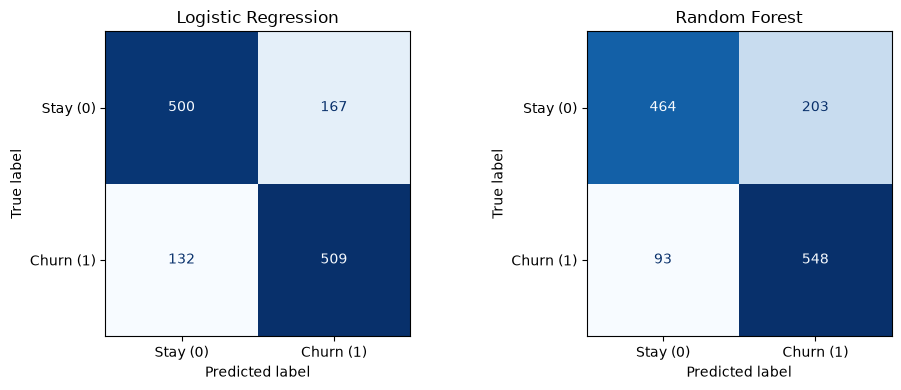

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, (y_pred, y_prob)) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["Stay (0)", "Churn (1)"], cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [12]:
for name, (y_pred, y_prob) in predictions.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(name)
    print("  TN (correct: Stay):", tn, "| FP (false alarm):", fp, "| FN (missed churn):", fn, "| TP (correct: Churn):", tp)

Logistic Regression
  TN (correct: Stay): 500 | FP (false alarm): 167 | FN (missed churn): 132 | TP (correct: Churn): 509
Random Forest
  TN (correct: Stay): 464 | FP (false alarm): 203 | FN (missed churn): 93 | TP (correct: Churn): 548


**The 4 parts of the confusion matrix (churn = "positive"):**

| Name | Meaning | In business terms |
|---|---|---|
| **TN** (True Negative) | The model said "will stay" and the customer stayed | Correct, nothing to do |
| **FP** (False Positive) | The model said "will leave" but the customer stayed | A discount was given for nothing (small loss) |
| **FN** (False Negative) | The model said "will stay" but the customer left | We lost a customer (big loss) |
| **TP** (True Positive) | The model said "will leave" and the customer left | Correct, we can try to keep this customer with an offer |

### ROC curve

The closer the curve is to the top-left corner, the better the model. The straight diagonal line means pure guessing.

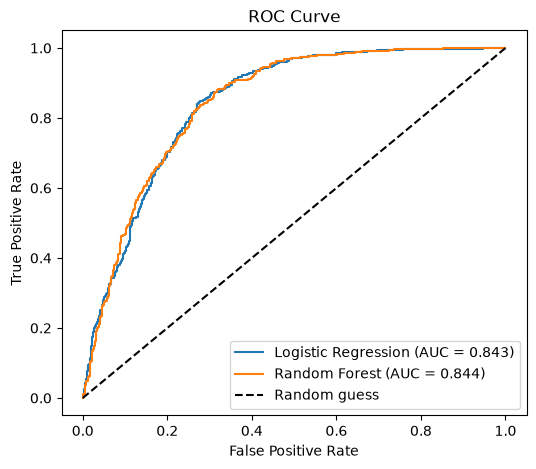

In [13]:
plt.figure(figsize=(6, 5))
for name, (y_pred, y_prob) in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name + " (AUC = " + str(round(roc_auc_score(y_test, y_prob), 3)) + ")")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Step 10: Which model will we use, and why?

**Rule:** we choose the model by **CV ROC-AUC** (the 5-fold average on the train data), not by the test score, so that the test data stays a final exam only.

In [14]:
best_name = results_df.sort_values("CV ROC-AUC", ascending=False).iloc[0]["Model"]
print("Chosen model:", best_name)
final_model = trained[best_name]

Chosen model: Logistic Regression


**We chose Logistic Regression. Reasons:**

1. **The scores are almost equal:** CV ROC-AUC 0.824 (Logistic) and 0.818 (Random Forest); test ROC-AUC 0.843 and 0.844; accuracy 0.771 and 0.774. Random Forest has a slightly higher recall (0.855) but a lower precision (0.730), so there is no clear overall winner.
2. **When the results are equal, the simple model is better:** Logistic Regression is fast and small (a small saved file, light for Streamlit).
3. **It is easy to explain:** the weight (coefficient) of every feature can be read, so we can tell the business why. Random Forest is more of a black box.
4. **Low risk of overfitting:** the CV score and the test score are close, so the model is not simply memorising the train data.
5. **The selection rule was fixed in advance** (highest CV ROC-AUC on the train data), so the test set was not used to choose the model.

**The real confusion matrix numbers (test set, 1,308 customers), Logistic Regression:** TP 509, FN 132, FP 167, TN 500. So out of 641 customers who really churned, the model caught 509 (Random Forest caught 548, at the price of more false alarms).

**How to read the metrics:**
- **Recall (0.79) and precision (0.75) are now close to each other**, so the model is fairly balanced: it catches about 8 out of 10 churners, and about 3 out of 4 of its "will churn" warnings are correct.
- **Accuracy alone is not enough:** 77% accuracy looks fine, but recall and ROC-AUC show how well the churners are caught. A missed churner (FN) costs more than a wasted discount (FP).
- **Honest note:** a ROC-AUC of about 0.84 means the model is **good, not perfect**. Some reasons for churn (customer service experience, competitors, price changes) are simply not in our data.

### Which features affect churn the most?

- **Logistic Regression:** the **weight (coefficient)** of each feature. A positive weight means that when this feature goes up, the churn chance **goes up**; a negative weight means it **goes down**. (The features are scaled, so the weights can be compared directly.)
- **Random Forest:** `feature_importances_` shows which feature helped the decisions the most.

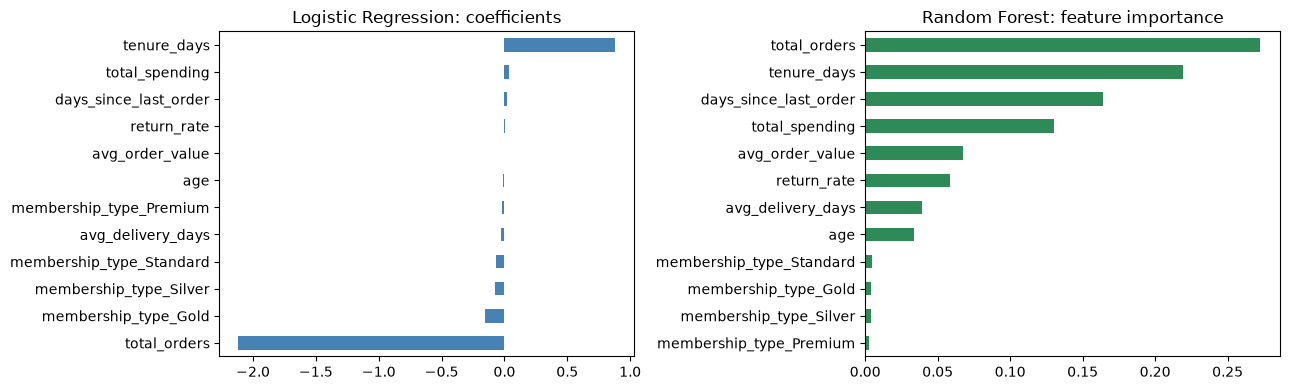

tenure_days                 0.883
total_spending              0.037
days_since_last_order       0.020
return_rate                 0.002
avg_order_value            -0.002
age                        -0.013
membership_type_Premium    -0.023
avg_delivery_days          -0.026
membership_type_Standard   -0.069
membership_type_Silver     -0.077
membership_type_Gold       -0.158
total_orders               -2.117
dtype: float64


In [15]:
feature_names = [n.split("__")[1] for n in trained["Logistic Regression"].named_steps["preprocess"].get_feature_names_out()]

lr_coefs = pd.Series(trained["Logistic Regression"].named_steps["model"].coef_[0], index=feature_names).sort_values()
rf_imp = pd.Series(trained["Random Forest"].named_steps["model"].feature_importances_, index=feature_names).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
lr_coefs.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Logistic Regression: coefficients")
rf_imp.plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Random Forest: feature importance")
plt.tight_layout()
plt.show()

print(lr_coefs.round(3).sort_values(ascending=False))

**Observation (what it means for the business):**
- **`total_orders` has the biggest effect** (weight about -2.12, negative): a customer who made more orders is **much less** likely to churn.
- **`tenure_days`** (weight about +0.88, positive): for the same number of orders, an **older account** is more likely to churn. In other words, a customer who has been around for a long time but orders rarely is losing interest.
- **`days_since_last_order` now has almost no weight** (about +0.02). Once the model knows `total_orders` and `tenure_days`, the recency adds little extra information.
- **Membership:** Gold customers churn slightly less (weight -0.16). The other features (age, return rate, delivery days, average order value) have **almost no effect**.
- The tiny positive weight of `total_spending` (+0.04) should not be read on its own, because it is strongly linked with `total_orders`.

**Business benefit:** the customers to worry about are the ones with **few orders compared to how long they have had an account**. Offers sent to these customers (and not to everyone) cost less and work better.

## Step 10b: Overfitting and Underfitting check

**What is overfitting?** The model **memorises the train data**, so it does very well on the train data but badly on new (test) data. (Like a student who only memorises old questions and fails on new ones.)

**What is underfitting?** The model is **too simple** and cannot learn the pattern, so it does badly on **both** the train and the test data.

**How do we check?** We compare the train score and the test score:

| Situation | Train score | Test score | Meaning |
|---|---|---|---|
| Good fit | good | about the same | all fine |
| **Overfitting** | very good | **much lower** | the model memorises |
| **Underfitting** | bad | bad | the model is weak, or the data has little signal |

In [16]:
rows = []
for name, pipe in trained.items():
    train_auc = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    rows.append({
        "Model": name,
        "Train Accuracy": round(train_acc, 3), "Test Accuracy": round(test_acc, 3),
        "Train ROC-AUC": round(train_auc, 3), "Test ROC-AUC": round(test_auc, 3),
        "AUC Gap (train - test)": round(train_auc - test_auc, 3),
    })

overfit_df = pd.DataFrame(rows)
overfit_df

,Model,Train Accuracy,Test Accuracy,Train ROC-AUC,Test ROC-AUC,AUC Gap (train - test)
0,Logistic Regression,0.743,0.771,0.826,0.843,-0.017
1,Random Forest,0.807,0.774,0.897,0.844,0.053


**Learning curve:** we give the model 20%, 40%, ... 100% of the data and watch how the train and validation scores change. Two lines that **come close and run together** = good. Train far above and validation much lower = overfitting.

Logistic Regression | last point -> Train: 0.826 | Validation: 0.824


Random Forest | last point -> Train: 0.906 | Validation: 0.818


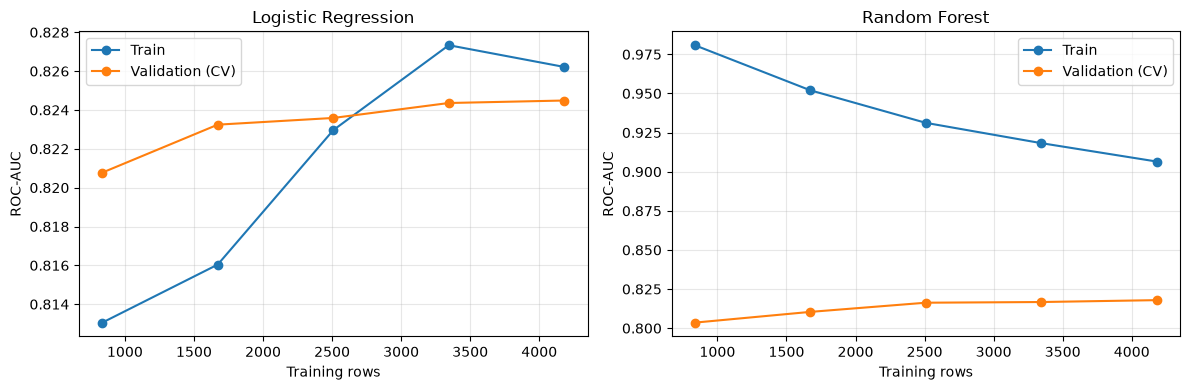

In [17]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, ["Logistic Regression", "Random Forest"]):
    sizes, train_scores, val_scores = learning_curve(
        trained[name], X_train, y_train, cv=cv, scoring="roc_auc",
        train_sizes=np.linspace(0.2, 1.0, 5))
    ax.plot(sizes, train_scores.mean(axis=1), "o-", label="Train")
    ax.plot(sizes, val_scores.mean(axis=1), "o-", label="Validation (CV)")
    print(name, "| last point -> Train:", round(train_scores.mean(axis=1)[-1], 3),
          "| Validation:", round(val_scores.mean(axis=1)[-1], 3))
    ax.set_title(name)
    ax.set_xlabel("Training rows")
    ax.set_ylabel("ROC-AUC")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Result (overfitting / underfitting):**

| Model | Train ROC-AUC | Test ROC-AUC | Gap | Verdict |
|---|---|---|---|---|
| Logistic Regression | 0.826 | 0.843 | -0.017 | **Good fit.** Train and test are close, and test is even slightly better (by chance) |
| Random Forest | 0.897 | 0.844 | +0.053 | **Slight overfitting.** Train is higher than test; in the learning curve the gap between train (0.91) and validation (0.82) stays |
| Neural Network | 0.836 | 0.841 | -0.005 | **Good fit.** Train and test are very close |

**The underfitting question:** the more powerful models (Random Forest, Neural Network) reached the same test ROC-AUC (about 0.84) as Logistic Regression. If Logistic Regression were too weak, a stronger model would do better. So the model is **not underfitting**; what limits the score now is the information in the data.

**Earlier version:** before adding `tenure_days` the same check gave a ROC-AUC of about 0.785 for every model. Adding one good feature moved all three models to about 0.84, which again shows that the data (features), not the algorithm, was the limit.

The **slight overfitting of Random Forest** could be reduced (with a smaller `max_depth`), but that would not raise the test score, so it is not the final model.

**Summary:** no model has **serious overfitting** and none is **underfitting**. The final model, Logistic Regression, is a good fit.

---
# Task E: Deep Learning (Neural Network)

**What is a neural network?** A model that works in layers of "neurons", a bit like the human brain. We use the **same churn data**; only the model is different.

**Architecture (32 -> 16 -> 1):**

| Layer | What it does |
|---|---|
| Input | 12 numbers (8 numeric + 4 membership 0/1 columns) |
| Dense 32 (`relu`) | 32 neurons; `relu` (the activation) turns negative values into 0 |
| Dense 16 (`relu`) | 16 neurons |
| Dense 1 (`sigmoid`) | 1 neuron that gives a probability between 0 and 1 (the chance of churn) |

**Loss function:** `binary_crossentropy`, the standard loss for a problem with two classes (0 or 1). **Optimizer:** `adam` (the algorithm that adjusts the weights).

**To avoid overfitting:** `validation_split=0.2` (20% of the train data is kept only for checking) and `EarlyStopping` (when the validation loss stops improving, training stops and the best weights are restored).

In [18]:
import tensorflow as tf
from tensorflow import keras

tf.keras.utils.set_random_seed(RANDOM_STATE)

# Same preprocessing as the ML models (already fitted on the train data)
prep = trained["Logistic Regression"].named_steps["preprocess"]
Xtr = prep.transform(X_train)
Xte = prep.transform(X_test)
if hasattr(Xtr, "toarray"):
    Xtr, Xte = Xtr.toarray(), Xte.toarray()

print("The neural network gets this shape:", Xtr.shape)

The neural network gets this shape: (5228, 12)


In [19]:
nn = keras.Sequential([
    keras.layers.Input(shape=(Xtr.shape[1],)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
])

nn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

history = nn.fit(Xtr, y_train.values, validation_split=0.2, epochs=100,
                 batch_size=64, callbacks=[early_stop], verbose=0)

print("Training stopped after", len(history.history["loss"]), "epochs (EarlyStopping)")
nn.summary()

Training stopped after 25 epochs (EarlyStopping)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,885 (11.27 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,924 (7.52 KB)

### Training graph (overfitting check)

Two lines: **train loss** and **validation loss**. If both go down together, all is fine. If the train loss keeps falling while the validation loss starts to rise, that is overfitting. `EarlyStopping` stops the training at that moment.

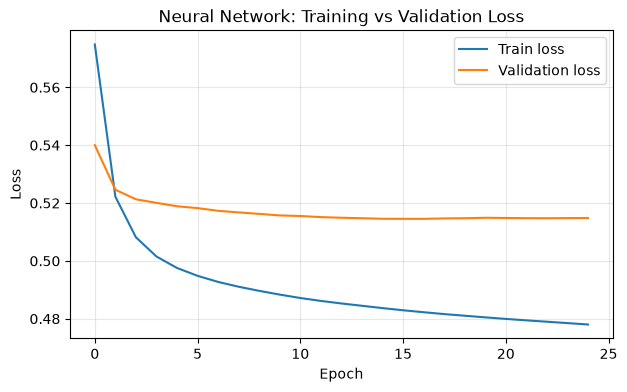

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Neural Network: Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Evaluate the neural network on the same test data

Exactly the same `X_test` and `y_test` that the ML models used, and the same metrics.

In [21]:
nn_prob = nn.predict(Xte, verbose=0).ravel()
nn_pred = (nn_prob >= 0.5).astype(int)

nn_row = {
    "Model": "Neural Network (32-16-1)",
    "CV ROC-AUC": np.nan,
    "Accuracy": round(accuracy_score(y_test, nn_pred), 3),
    "Precision": round(precision_score(y_test, nn_pred), 3),
    "Recall": round(recall_score(y_test, nn_pred), 3),
    "F1": round(f1_score(y_test, nn_pred), 3),
    "ROC-AUC": round(roc_auc_score(y_test, nn_prob), 3),
}

all_results = pd.concat([results_df, pd.DataFrame([nn_row])], ignore_index=True)
all_results

,Model,CV ROC-AUC,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.824,0.771,0.753,0.794,0.773,0.843
1,Random Forest,0.818,0.774,0.730,0.855,0.787,0.844
2,Neural Network (32-16-1),NaN,0.778,0.734,0.858,0.791,0.841


In [22]:
tn, fp, fn, tp = confusion_matrix(y_test, nn_pred).ravel()
print("Neural Network | TN:", tn, "| FP:", fp, "| FN:", fn, "| TP:", tp)

nn_train_auc = roc_auc_score(y_train, nn.predict(Xtr, verbose=0).ravel())
nn_test_auc = roc_auc_score(y_test, nn_prob)
print("NN Train ROC-AUC:", round(nn_train_auc, 3), "| Test ROC-AUC:", round(nn_test_auc, 3),
      "| Gap:", round(nn_train_auc - nn_test_auc, 3))

Neural Network | TN: 468 | FP: 199 | FN: 91 | TP: 550


NN Train ROC-AUC: 0.836 | Test ROC-AUC: 0.841 | Gap: -0.005


### Result and comparison of Deep Learning

| Model | Accuracy | Recall | F1 | ROC-AUC |
|---|---|---|---|---|
| Logistic Regression | 0.771 | 0.794 | 0.773 | 0.843 |
| Random Forest | 0.774 | 0.855 | 0.787 | 0.844 |
| Neural Network (32-16-1) | 0.778 | 0.858 | 0.791 | 0.841 |

**Was Deep Learning worth it?** No. The neural network is only a tiny bit better in accuracy (0.778 against 0.771) and recall, and its ROC-AUC is even slightly lower (0.841 against 0.843). Such small differences are within normal random variation. The neural network also needs more code, a heavy library like TensorFlow, tuning (epochs, layers) and more time, and unlike Logistic Regression it cannot be explained (which feature has how much effect). This data has only 6,536 rows and 9 simple features, so a small ML model is enough. **The final model stays Logistic Regression**, and the Streamlit app uses it (light, fast and easy to understand).

## Step 11: Save the model and test it again after loading

`final_model` contains both the preprocessing and the model, so after loading we can give it raw customer data directly.

In [23]:
joblib.dump(final_model, "churn_model.pkl")
print("Saved: churn_model.pkl")

Saved: churn_model.pkl


In [24]:
loaded_model = joblib.load("churn_model.pkl")

new_customer = pd.DataFrame([{
    "total_orders": 3,
    "total_spending": 45000,
    "avg_order_value": 15000,
    "days_since_last_order": 200,
    "return_rate": 0.0,
    "avg_delivery_days": 3.5,
    "age": 28,
    "membership_type": "Standard",
    "tenure_days": 300,
}])

pred = loaded_model.predict(new_customer)[0]
prob = loaded_model.predict_proba(new_customer)[0][1]
print("Prediction:", "CHURN" if pred == 1 else "STAY")
print("Churn probability:", round(prob * 100, 1), "%")

same = (loaded_model.predict(X_test) == final_model.predict(X_test)).all()
print("The loaded model gives the same predictions as the original:", same)

Prediction: STAY
Churn probability: 36.2 %
The loaded model gives the same predictions as the original: True


**Result:** `churn_model.pkl` loads correctly and gives a prediction and a probability for a new customer. The Streamlit app uses this same file.

---
### Summary (Task D and E)

| Item | Result |
|---|---|
| Customers (bought up to 31 May) | 6,536 |
| Churn rate | about 49% |
| Features | 9 (the 8 required ones + the engineered feature `tenure_days`) |
| Models | Logistic Regression, Random Forest, Neural Network (32-16-1) |
| Test ROC-AUC | 0.843 / 0.844 / 0.841 (almost equal) |
| Test accuracy | 0.771 / 0.774 / 0.778 |
| Effect of `tenure_days` | accuracy 0.720 to 0.771, ROC-AUC 0.785 to 0.843 |
| Overfitting / Underfitting | no serious overfitting (Random Forest slightly), no underfitting |
| Final model | Logistic Regression (`churn_model.pkl`) |
| Most important features | `total_orders` (more orders = less churn), `tenure_days` (old account with few orders = more churn) |

To avoid leakage, all features were built only from orders up to 31 May (plus the signup date, which is known before that date), and the target (churn) only from the orders of 1 June to 31 August.